In [1]:
%matplotlib inline

TASK 2: CROSSING OUTPUT OF MIDFIELDERS

STEP 1-2: LOADING AND WRANGLING
Loaded 1039 rows from wc2026_misc.csv
  Dropped 0 rows with missing key values
  Removed 62 goalkeepers
  Removed 485 players under 2.0 x 90 minutes
  Final outfield pool: 492 players (217 midfielders)

BENCHMARKS (crosses per 90 minutes)
  All outfield players : 1.522
  DF and FW only       : 1.194

SAMPLING
  Population size (midfielders) : 217
  Sample size                   : 50
  Sampling fraction             : 23.0%
  Technique                     : simple random, seed 42

DESCRIPTIVE STATISTICS (sample, crosses per 90)
  n               : 50
  Mean            : 1.874
  Median          : 0.964
  Std deviation   : 2.217
  Min / Max       : 0.000 / 10.227
  Q1 / Q3         : 0.282 / 2.610
  Skewness        : 1.692
  Excess kurtosis : 3.109
  Shape           : right-skewed (a tail of high-volume crossers)
  Note: right skew is normal for rate data bounded below by 0.

NORMALITY CHECK (Shapiro-Wilk)
  W statistic

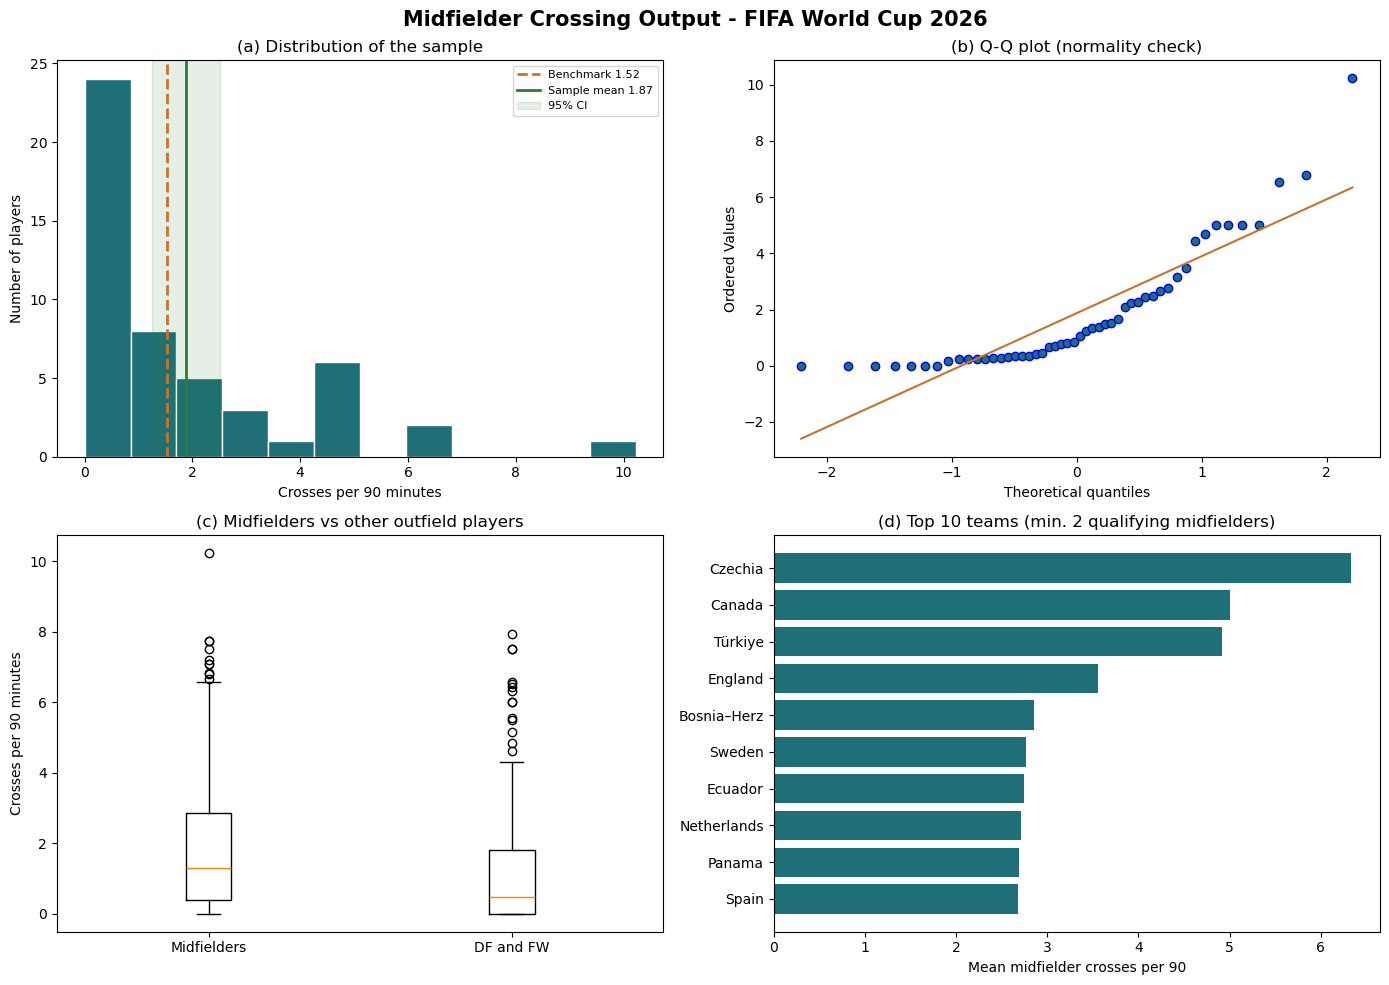

In [3]:
"""
HIT140 Foundations of Data Science
Objective 1 - Analytic Task 2: Attacking Delivery

AUTHOR   : Nasid Alve
STUDENT  : S396257
UNIT     : HIT140 Foundations of Data Science
TASK     : Objective 1, Analytic Task 2 of 4
DATE     : September 2026

DATA SOURCE
    FBref.com (Sports Reference LLC), 2026 FIFA World Cup Miscellaneous Stats.
    Retrieved September 2026 from fbref.com/en/comps/1/misc/World-Cup-Stats

ANALYTIC QUESTION
    Do midfielders at the FIFA World Cup 2026 deliver more crosses per 90
    minutes than the tournament-wide average for all outfield players?

FOCAL POINT
    Chance creation from wide areas. This is deliberately distinct from the
    disciplinary focus of Task 1: crossing is an attacking action measuring
    how a player supplies the box, not an infringement of the laws.

WHY THIS METRIC
    Raw cross counts are unfair to compare: a player who appeared in seven
    matches has far more opportunity to cross than one who played two. Dividing
    crosses by 90s turns the count into a RATE, so every player is compared on
    equal terms. This is the most important decision in the analysis.
"""

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt


# =============================================================================
# CONFIGURATION - every value here is a decision you must be able to justify
# =============================================================================

DATA_FILE = "wc2026_misc.csv"

COL_PLAYER = "Player"
COL_TEAM = "Squad"
COL_POSITION = "Pos"        # "MF", "DF,MF", "FWMF", "GK", ...
COL_NINETIES = "90s"        # number of 90-minute periods played
COL_CROSSES = "Crs"         # crosses delivered

MIN_90S = 2.0        # = 180 minutes. Two full matches.
SAMPLE_SIZE = 50     # n >= 30 so the Central Limit Theorem applies
RANDOM_SEED = 42     # fixes the sample so results reproduce exactly
ALPHA = 0.05

POSITION_RULE = "primary"   # "primary" = first listed position only


# =============================================================================
# STEP 1 - LOAD
# =============================================================================

def load_data(path):
    """Read the CSV and force the numeric columns to be numeric.

    FBref repeats its header row every 25 lines and uses commas in large
    numbers. Coercing to numeric turns anything unparseable into NaN so we can
    drop it deliberately instead of having it break the arithmetic silently.
    """
    df = pd.read_csv(path)

    # FBref sometimes carries an extra ",,,,,Performance" line above the real
    # header. If the real column names aren't found, retry skipping line one.
    if COL_PLAYER not in df.columns:
        print("  Extra header row detected, re-reading with skiprows=1")
        df = pd.read_csv(path, skiprows=1)

    if COL_PLAYER in df.columns:
        df = df[df[COL_PLAYER].astype(str) != COL_PLAYER]

    for col in [COL_NINETIES, COL_CROSSES]:
        if col not in df.columns:
            raise KeyError(
                f"Column '{col}' not found. Your file has: {list(df.columns)}"
            )
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace(",", "", regex=False),
            errors="coerce",
        )

    # FBref prefixes country codes onto squad names: "us USA", "eg Egypt".
    if COL_TEAM in df.columns:
        df[COL_TEAM] = (
            df[COL_TEAM].astype(str)
            .str.replace(r"^[a-z]{2,3}\s+", "", regex=True)
            .str.strip()
        )

    print(f"Loaded {len(df)} rows from {path}")
    if len(df) < 100:
        print("  WARNING: very few rows. Did you click 'Show hidden rows'?")
    return df


# =============================================================================
# STEP 2 - WRANGLING
# =============================================================================

def primary_position(pos):
    """FBref writes hybrids two ways: 'DF,MF' and 'FWMF'. Taking the first two
    characters gives the primary position either way."""
    return str(pos).strip().upper()[:2]


def is_goalkeeper(pos):
    return primary_position(pos) == "GK"


def is_midfielder(pos, rule=POSITION_RULE):
    pos = str(pos).strip().upper()
    if rule == "primary":
        return primary_position(pos) == "MF"
    return "MF" in pos


def wrangle(df):
    """Clean, filter, and compute the crosses-per-90 rate."""
    start = len(df)

    df = df.dropna(subset=[COL_CROSSES, COL_NINETIES, COL_POSITION]).copy()
    print(f"  Dropped {start - len(df)} rows with missing key values")

    # Goalkeepers essentially never cross; including them would drag the
    # outfield benchmark artificially downward.
    before = len(df)
    df = df[~df[COL_POSITION].apply(is_goalkeeper)].copy()
    print(f"  Removed {before - len(df)} goalkeepers")

    # A player with 0.2 of a 90 who delivered one cross has a rate of 5 per 90
    # - technically true, statistically noise.
    before = len(df)
    df = df[df[COL_NINETIES] >= MIN_90S].copy()
    print(f"  Removed {before - len(df)} players under {MIN_90S} x 90 minutes")

    # THE KEY TRANSFORMATION: convert a count into a rate.
    df["crosses_per_90"] = df[COL_CROSSES] / df[COL_NINETIES]
    df["is_mid"] = df[COL_POSITION].apply(is_midfielder)

    print(f"  Final outfield pool: {len(df)} players "
          f"({df['is_mid'].sum()} midfielders)")
    return df


# =============================================================================
# STEP 3 - BENCHMARK
# =============================================================================

def compute_benchmarks(df):
    """mu_all      all outfield players. Matches the question as written, but
                   midfielders sit inside it, so the test is conservative.
       mu_non_mid  defenders and forwards only - no overlap with the sample."""
    mu_all = df["crosses_per_90"].mean()
    mu_non_mid = df.loc[~df["is_mid"], "crosses_per_90"].mean()

    print("\nBENCHMARKS (crosses per 90 minutes)")
    print(f"  All outfield players : {mu_all:.3f}")
    print(f"  DF and FW only       : {mu_non_mid:.3f}")
    return mu_all, mu_non_mid


# =============================================================================
# STEP 4 - POPULATION AND SAMPLING
# =============================================================================

def draw_sample(df):
    """POPULATION: every midfielder meeting the playing-time threshold.
    SAMPLE: SAMPLE_SIZE drawn without replacement.

    Why sample when the whole population is available? Because the task is to
    demonstrate statistical inference - estimating an unknown parameter from
    limited data. Simple random sampling gives every midfielder an equal
    selection probability. random_state fixes the draw so results reproduce.
    """
    population = df[df["is_mid"]].copy()
    n_pop = len(population)

    if n_pop < SAMPLE_SIZE:
        raise ValueError(f"Only {n_pop} midfielders but SAMPLE_SIZE is {SAMPLE_SIZE}.")

    sample = population.sample(n=SAMPLE_SIZE, random_state=RANDOM_SEED)

    print("\nSAMPLING")
    print(f"  Population size (midfielders) : {n_pop}")
    print(f"  Sample size                   : {len(sample)}")
    print(f"  Sampling fraction             : {len(sample)/n_pop:.1%}")
    print(f"  Technique                     : simple random, seed {RANDOM_SEED}")
    return population, sample


# =============================================================================
# STEP 5 - DESCRIPTIVE STATISTICS
# =============================================================================

def describe(sample):
    x = sample["crosses_per_90"]
    d = {"n": len(x), "mean": x.mean(), "median": x.median(),
         "std": x.std(ddof=1), "min": x.min(), "max": x.max(),
         "q1": x.quantile(0.25), "q3": x.quantile(0.75),
         "skew": x.skew(), "kurtosis": x.kurtosis()}

    print("\nDESCRIPTIVE STATISTICS (sample, crosses per 90)")
    print(f"  n               : {d['n']}")
    print(f"  Mean            : {d['mean']:.3f}")
    print(f"  Median          : {d['median']:.3f}")
    print(f"  Std deviation   : {d['std']:.3f}")
    print(f"  Min / Max       : {d['min']:.3f} / {d['max']:.3f}")
    print(f"  Q1 / Q3         : {d['q1']:.3f} / {d['q3']:.3f}")
    print(f"  Skewness        : {d['skew']:.3f}")
    print(f"  Excess kurtosis : {d['kurtosis']:.3f}")

    if abs(d["skew"]) < 0.5:
        shape = "roughly symmetric"
    elif d["skew"] > 0:
        shape = "right-skewed (a tail of high-volume crossers)"
    else:
        shape = "left-skewed"
    print(f"  Shape           : {shape}")
    if d["skew"] > 0.5:
        print("  Note: right skew is normal for rate data bounded below by 0.")
    return d


# =============================================================================
# STEP 6 - NORMALITY
# =============================================================================

def check_normality(sample):
    """Shapiro-Wilk.  H0: the data are normally distributed.

    Cross rates come from counts, cannot go below zero, and many central
    midfielders record none at all, so right skew is very likely and this test
    may well fail. That is not a problem: with n >= 30 the Central Limit
    Theorem means the SAMPLING DISTRIBUTION OF THE MEAN is approximately
    normal regardless, so the t-test stays robust.
    """
    x = sample["crosses_per_90"]
    stat, p = stats.shapiro(x)

    print("\nNORMALITY CHECK (Shapiro-Wilk)")
    print(f"  W statistic : {stat:.4f}")
    print(f"  p-value     : {p:.4f}")

    if p > ALPHA:
        print(f"  p > {ALPHA}: no evidence against normality. t-test is fine.")
    else:
        print(f"  p <= {ALPHA}: normality questionable (expected for rate data).")
        print(f"  With n = {len(x)} the CLT still supports the t-test; the")
        print("  Wilcoxon result below is reported as confirmation.")
    return p > ALPHA, p


# =============================================================================
# STEP 7 - CONFIDENCE INTERVAL
# =============================================================================

def confidence_interval(sample, conf=0.95):
    """CI = xbar +/- t(alpha/2, n-1) * (s / sqrt(n))

    The t-distribution is correct because the population standard deviation is
    unknown and estimated from the sample.

    Interpretation: repeating this sampling procedure many times would produce
    intervals containing the true population mean about 95% of the time. It is
    NOT a 95% probability for this particular interval.
    """
    x = sample["crosses_per_90"]
    n, mean = len(x), x.mean()
    se = x.std(ddof=1) / np.sqrt(n)
    t_crit = stats.t.ppf((1 + conf) / 2, n - 1)
    margin = t_crit * se

    print(f"\n{int(conf*100)}% CONFIDENCE INTERVAL")
    print(f"  Standard error     : {se:.4f}")
    print(f"  Degrees of freedom : {n-1}")
    print(f"  t critical value   : {t_crit:.4f}")
    print(f"  Margin of error    : {margin:.4f}")
    print(f"  Interval           : [{mean-margin:.3f}, {mean+margin:.3f}]")
    return mean - margin, mean + margin


# =============================================================================
# STEP 8 - ONE-SAMPLE t-TEST
# =============================================================================

def one_sample_test(sample, mu_0, label, normal_ok):
    """H0: mu_midfielders <= mu_0      H1: mu_midfielders > mu_0

    ONE-TAILED because the question asks whether midfielders deliver MORE
    crosses, not merely a different number. alternative='greater' places the
    entire rejection region in the upper tail.
    """
    x = sample["crosses_per_90"]
    t_stat, p_val = stats.ttest_1samp(x, popmean=mu_0, alternative="greater")

    d = (x.mean() - mu_0) / x.std(ddof=1)
    size = ("negligible" if abs(d) < 0.2 else
            "small" if abs(d) < 0.5 else
            "medium" if abs(d) < 0.8 else "large")

    print(f"\nONE-SAMPLE t-TEST vs {label} ({mu_0:.3f})")
    print(f"  Sample mean : {x.mean():.3f} crosses per 90")
    print(f"  Difference  : {x.mean()-mu_0:+.3f}")
    print(f"  t statistic : {t_stat:.4f}")
    print(f"  p-value     : {p_val:.4f}  (one-tailed)")
    print(f"  Cohen's d   : {d:.3f} ({size} effect)")

    if p_val < ALPHA:
        print(f"  DECISION: reject H0 at alpha = {ALPHA}.")
        print("  Midfielders deliver significantly more crosses per 90.")
    else:
        print(f"  DECISION: fail to reject H0 at alpha = {ALPHA}.")
        print("  Insufficient evidence that midfielders cross more often.")

    # Non-parametric robustness check, run ALWAYS. If a test that assumes
    # nothing about the distribution reaches the same conclusion, the finding
    # is clearly not an artefact of the t-test's assumptions.
    w_stat, w_p = stats.wilcoxon(x - mu_0, alternative="greater")
    agree = "agrees with" if (w_p < ALPHA) == (p_val < ALPHA) else "DISAGREES with"
    print(f"  Wilcoxon signed-rank check: p = {w_p:.4f} ({agree} the t-test)")

    return {"t": t_stat, "p": p_val, "d": d, "size": size,
            "mean": x.mean(), "mu_0": mu_0, "wilcoxon_p": w_p,
            "reject": p_val < ALPHA, "label": label}


# =============================================================================
# STEP 9 - VISUALISATIONS
# =============================================================================

def make_plots(sample, population, df, mu_0, ci):
    x = sample["crosses_per_90"]
    lower, upper = ci

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Midfielder Crossing Output - FIFA World Cup 2026",
                 fontsize=15, fontweight="bold")

    ax = axes[0, 0]
    ax.hist(x, bins=12, color="#1F6F78", edgecolor="white")
    ax.axvline(mu_0, color="#C9722B", linestyle="--", linewidth=2,
               label=f"Benchmark {mu_0:.2f}")
    ax.axvline(x.mean(), color="#2E7D32", linewidth=2,
               label=f"Sample mean {x.mean():.2f}")
    ax.axvspan(lower, upper, color="#2E7D32", alpha=0.12, label="95% CI")
    ax.set_xlabel("Crosses per 90 minutes")
    ax.set_ylabel("Number of players")
    ax.set_title("(a) Distribution of the sample")
    ax.legend(fontsize=8)

    ax = axes[0, 1]
    stats.probplot(x, dist="norm", plot=ax)
    ax.set_title("(b) Q-Q plot (normality check)")
    ax.get_lines()[0].set_markerfacecolor("#1F6F78")
    ax.get_lines()[1].set_color("#C9722B")

    ax = axes[1, 0]
    ax.boxplot([population["crosses_per_90"],
                df.loc[~df["is_mid"], "crosses_per_90"]],
               tick_labels=["Midfielders", "DF and FW"])
    ax.set_ylabel("Crosses per 90 minutes")
    ax.set_title("(c) Midfielders vs other outfield players")

    ax = axes[1, 1]
    top = population.groupby(COL_TEAM)["crosses_per_90"].agg(["mean", "count"])
    top = top[top["count"] >= 2].sort_values("mean", ascending=False).head(10)
    ax.barh(top.index[::-1], top["mean"][::-1], color="#1F6F78")
    ax.set_xlabel("Mean midfielder crosses per 90")
    ax.set_title("(d) Top 10 teams (min. 2 qualifying midfielders)")

    plt.tight_layout()
    plt.savefig("task2_crosses_analysis.png", dpi=200, bbox_inches="tight")
    print("\nSaved charts to task2_crosses_analysis.png")
    plt.show()


# =============================================================================
# STEP 10 - SAVE EVERYTHING FOR SUBMISSION AND SLIDES
# =============================================================================

def save_outputs(df, population, sample, desc, shapiro_p, ci, primary, sensitivity):
    """Write results_summary.txt (all numbers, slide by slide), plus the
    cleaned pool and the exact sample, so a marker can verify your figures."""
    lo, hi = ci
    lines = [
        "=" * 60,
        "TASK 2 RESULTS - CROSSING OUTPUT OF MIDFIELDERS",
        "Nasid Alve (S396257) - HIT140 Foundations of Data Science",
        "Data: FBref.com, 2026 FIFA World Cup Miscellaneous Stats",
        "=" * 60, "",
        "ANALYTIC QUESTION",
        "  Do midfielders deliver more crosses per 90 minutes than the",
        "  tournament-wide average for all outfield players?", "",
        "-" * 60, "SLIDE 2 - DATA PREPARATION AND SAMPLING", "-" * 60,
        f"  Outfield pool after filtering : {len(df)}",
        f"  Population (midfielders)      : {len(population)}",
        f"  Sample size                   : {len(sample)}",
        f"  Sampling fraction             : {len(sample)/len(population):.1%}",
        f"  Technique                     : simple random, seed {RANDOM_SEED}",
        f"  Minimum playing time          : {MIN_90S} x 90 minutes", "",
        "-" * 60, "SLIDE 3 - DESCRIPTIVE STATISTICS", "-" * 60,
        f"  Mean            : {desc['mean']:.3f} crosses per 90",
        f"  Median          : {desc['median']:.3f}",
        f"  Std deviation   : {desc['std']:.3f}",
        f"  Min / Max       : {desc['min']:.3f} / {desc['max']:.3f}",
        f"  Skewness        : {desc['skew']:.3f}", "",
        "-" * 60, "SLIDE 3 - ASSUMPTIONS AND CONFIDENCE INTERVAL", "-" * 60,
        f"  Shapiro-Wilk p-value : {shapiro_p:.4f}",
        f"  Normality            : {'assumption met' if shapiro_p > ALPHA else 'questionable, CLT applies'}",
        f"  95% CI               : [{lo:.3f}, {hi:.3f}]", "",
        "-" * 60, "SLIDE 3 - HYPOTHESIS TEST", "-" * 60,
        f"  Benchmark      : {primary['mu_0']:.3f}",
        f"  Sample mean    : {primary['mean']:.3f}",
        f"  Difference     : {primary['mean'] - primary['mu_0']:+.3f}",
        f"  t statistic    : {primary['t']:.4f}",
        f"  p-value        : {primary['p']:.4f} (one-tailed)",
        f"  Cohen's d      : {primary['d']:.3f} ({primary['size']})",
        f"  DECISION       : {'REJECT' if primary['reject'] else 'FAIL TO REJECT'} H0 at alpha = {ALPHA}",
        f"  Wilcoxon check : p = {primary['wilcoxon_p']:.4f}", "",
        "-" * 60, "SLIDE 4 - SENSITIVITY CHECK (benchmark excludes midfielders)", "-" * 60,
        f"  Benchmark   : {sensitivity['mu_0']:.3f}",
        f"  t statistic : {sensitivity['t']:.4f}",
        f"  p-value     : {sensitivity['p']:.4f}",
        f"  DECISION    : {'REJECT' if sensitivity['reject'] else 'FAIL TO REJECT'} H0",
        f"  Conclusion  : {'HELD' if primary['reject'] == sensitivity['reject'] else 'CHANGED'}",
        "", "=" * 60,
    ]
    with open("results_summary.txt", "w", encoding="utf-8") as f:
        f.write("\n".join(lines))

    df.to_csv("cleaned_data.csv", index=False)
    sample.to_csv("sample_used.csv", index=False)

    print("\nFILES SAVED")
    print("  results_summary.txt  <- all numbers for your slides")
    print("  cleaned_data.csv     <- filtered outfield pool")
    print("  sample_used.csv      <- the 50 midfielders analysed")


# =============================================================================
# MAIN
# =============================================================================

def main():
    print("=" * 68)
    print("TASK 2: CROSSING OUTPUT OF MIDFIELDERS")
    print("=" * 68)

    print("\nSTEP 1-2: LOADING AND WRANGLING")
    df = wrangle(load_data(DATA_FILE))

    mu_all, mu_non_mid = compute_benchmarks(df)
    population, sample = draw_sample(df)
    desc = describe(sample)
    normal_ok, shapiro_p = check_normality(sample)
    ci = confidence_interval(sample)

    primary = one_sample_test(sample, mu_all, "all-outfield benchmark", normal_ok)

    print("\n" + "-" * 68)
    print("SENSITIVITY CHECK (benchmark excludes midfielders)")
    print("-" * 68)
    sensitivity = one_sample_test(sample, mu_non_mid, "DF and FW benchmark", normal_ok)

    save_outputs(df, population, sample, desc, shapiro_p, ci, primary, sensitivity)
    make_plots(sample, population, df, mu_all, ci)

    

main()

In [4]:
print(open('results_summary.txt', encoding='utf-8').read())

TASK 2 RESULTS - CROSSING OUTPUT OF MIDFIELDERS
Nasid Alve (S396257) - HIT140 Foundations of Data Science
Data: FBref.com, 2026 FIFA World Cup Miscellaneous Stats

ANALYTIC QUESTION
  Do midfielders deliver more crosses per 90 minutes than the
  tournament-wide average for all outfield players?

------------------------------------------------------------
SLIDE 2 - DATA PREPARATION AND SAMPLING
------------------------------------------------------------
  Outfield pool after filtering : 492
  Population (midfielders)      : 217
  Sample size                   : 50
  Sampling fraction             : 23.0%
  Technique                     : simple random, seed 42
  Minimum playing time          : 2.0 x 90 minutes

------------------------------------------------------------
SLIDE 3 - DESCRIPTIVE STATISTICS
------------------------------------------------------------
  Mean            : 1.874 crosses per 90
  Median          : 0.964
  Std deviation   : 2.217
  Min / Max       : 0.000 / 10.